In [147]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from scipy.stats import randint
from sklearn.model_selection import RepeatedStratifiedKFold


In [73]:
file_path = "../4.DATA CLEANING/CMI_V2_CONTROL.csv"
df=pd.read_csv(file_path)
df.head(5)

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-HeartRate,Fitness_Endurance-Max_Stage,FGC-FGC_TL,...,BIA-BIA_TBW,PCIAT-PCIAT_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,PCIAT-PCIAT_Total_CAL,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,0,5,0,51.0,16.877316,46.0,50.8,NaN,5.0,6.0,...,32.6909,55.0,NaN,3.0,2.0,55.0,NaN,0.0,NaN,6.5
1,1,9,0,NaN,14.035590,48.0,46.0,70.0,NaN,3.0,...,27.0552,0.0,64.0,0.0,0.0,0.0,90.666667,8.0,NaN,11.0
2,2,10,1,71.0,16.648696,56.5,75.6,94.0,5.0,5.0,...,44.9870,28.0,54.0,2.0,0.0,28.0,82.333333,27.0,12.45,10.0
3,3,9,0,71.0,18.292347,56.0,81.6,97.0,6.0,7.0,...,45.9966,44.0,45.0,0.0,1.0,44.0,79.000000,23.0,NaN,7.0
4,4,18,1,65.0,17.937682,NaN,77.0,NaN,NaN,10.0,...,NaN,NaN,NaN,1.0,0.0,0.0,NaN,12.0,NaN,NaN


In [74]:
df.columns

Index(['id', 'Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score',
       'Physical-BMI', 'Physical-Height', 'Physical-Weight',
       'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMI', 'BIA-BIA_BMC',
       'BIA-BIA_DEE', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat',
       'BIA-BIA_Frame_num', 'BIA-BIA_SMM', 'BIA-BIA_TBW', 'PCIAT-PCIAT_Total',
       'SDS-SDS_Total_T', 'PreInt_EduHx-computerinternet_hoursday', 'sii',
       'PCIAT-PCIAT_Total_CAL', 'Physical-MAP_CAL', 'FGC-FGC_CORE_CAL',
       'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL'],
      dtype='object')

In [75]:
df_reg = df[(df['Physical-Height'] != 0) & (df['Physical-Weight'] != 0) & (df['Physical-BMI'] != 0)]

In [76]:
df_reg = df_reg.dropna(subset=['Physical-Weight', 'Physical-Height','Physical-BMI'])

In [123]:
cols = ['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score','Physical-BMI', 'Physical-Height', 'Physical-Weight', 'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMI', 'BIA-BIA_BMC','BIA-BIA_DEE', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat',
       'BIA-BIA_Frame_num', 'BIA-BIA_SMM', 'BIA-BIA_TBW', 'PCIAT-PCIAT_Total','SDS-SDS_Total_T', 'PreInt_EduHx-computerinternet_hoursday', 'sii','PCIAT-PCIAT_Total_CAL', 'Physical-MAP_CAL', 'FGC-FGC_CORE_CAL',
       'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL']   

for col in cols:
    df_reg = df_reg.dropna(subset=[col])


In [124]:
df_reg.isnull().sum()

id                                        0
Basic_Demos-Age                           0
Basic_Demos-Sex                           0
CGAS-CGAS_Score                           0
Physical-BMI                              0
Physical-Height                           0
Physical-Weight                           0
Physical-HeartRate                        0
Fitness_Endurance-Max_Stage               0
FGC-FGC_TL                                0
BIA-BIA_Activity_Level_num                0
BIA-BIA_BMI                               0
BIA-BIA_BMC                               0
BIA-BIA_DEE                               0
BIA-BIA_FFMI                              0
BIA-BIA_FMI                               0
BIA-BIA_Fat                               0
BIA-BIA_Frame_num                         0
BIA-BIA_SMM                               0
BIA-BIA_TBW                               0
PCIAT-PCIAT_Total                         0
SDS-SDS_Total_T                           0
PreInt_EduHx-computerinternet_ho

In [80]:
df_reg['Physical-Height'].describe()

count    6544.000000
mean       57.171377
std         7.541793
min        33.000000
25%        51.115000
50%        56.000000
75%        63.000000
max        78.500000
Name: Physical-Height, dtype: float64

In [81]:
df_reg['Physical-Weight'].describe()


count    6544.000000
mean       86.125241
std        40.481227
min         0.700000
25%        55.400000
50%        74.100000
75%       109.800000
max       315.000000
Name: Physical-Weight, dtype: float64

In [125]:
X = df_reg[['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score','Physical-Height', 'Physical-Weight',
       'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMI', 'BIA-BIA_BMC',
       'BIA-BIA_DEE', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat',
       'BIA-BIA_Frame_num', 'BIA-BIA_SMM', 'BIA-BIA_TBW', 'PCIAT-PCIAT_Total',
       'SDS-SDS_Total_T', 'PreInt_EduHx-computerinternet_hoursday', 'sii',
       'PCIAT-PCIAT_Total_CAL', 'Physical-MAP_CAL', 'FGC-FGC_CORE_CAL',
       'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL']].values 
y = df_reg['Physical-BMI'].values 

In [126]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

### Decision Tree

In [127]:
reg = DecisionTreeRegressor()

In [128]:
reg.fit(X_train, y_train)

DecisionTreeRegressor()

In [129]:
y_pred = reg.predict(X_test)
y_pred

array([26.64857002, 15.18977316, 24.56353361, 18.68058431, 16.24903978,
       15.28388172, 20.15656337, 20.32030599, 19.75130073, 17.66466837,
       18.71555594, 19.42792301, 22.06801427, 16.67596197, 19.86103018,
       12.64913495, 22.71399584, 19.64552528, 31.9236715 , 16.17144097,
       25.28758672, 20.55555556, 26.59683333, 17.80295692, 21.96110949,
       29.1183432 , 20.71210862, 15.81687433, 17.51868993, 21.23143195,
       15.27514648, 14.64099174, 18.1398823 , 21.33632835, 15.85590101,
       21.67988754, 23.75789474, 23.68505859, 24.02465125, 17.00448147,
       19.75130073, 16.7892127 , 18.83631557, 16.9820908 , 19.267717  ,
       17.66214876, 17.86271934, 14.02811791, 18.45607561, 32.11771029,
       21.90931322, 21.88938461, 22.08816414, 16.43671056, 24.0797184 ,
       19.28555908, 17.25405405, 15.96096939, 14.81138024, 20.71210862,
       14.73722311, 17.26568   , 17.26568   , 19.62374936, 20.53437653,
       30.34178984, 18.26341926, 24.09028405, 27.06632894, 18.68

In [130]:
print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))

R2: 0.920
MSE: 1.531
MAE: 0.366


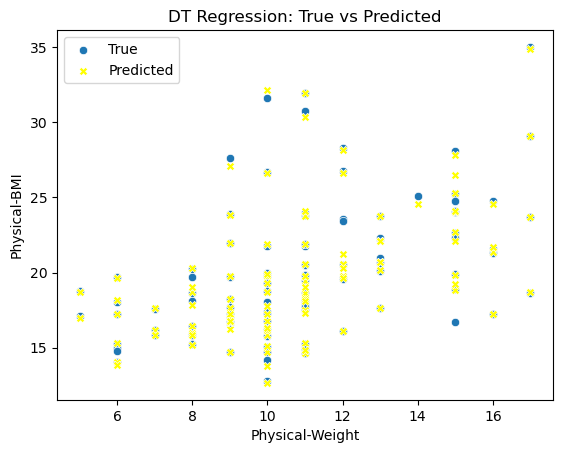

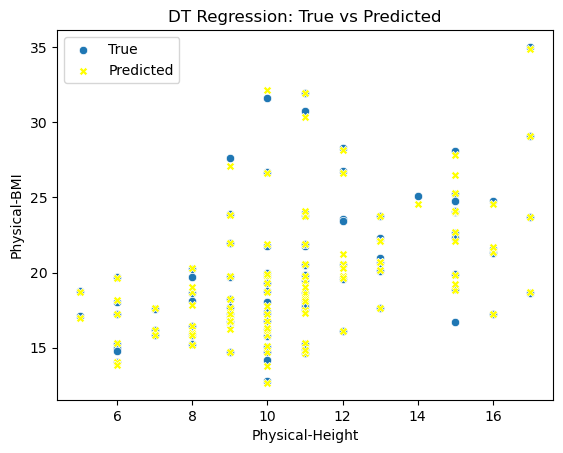

In [143]:
test_df = pd.DataFrame({
    'Physical-Weight': X_test[:, 0],
    'Physical-BMI': y_test})

sns.scatterplot(data=test_df, x='Physical-Weight', y='Physical-BMI', label="True")
sns.scatterplot(data=test_df, x='Physical-Weight', y=reg.predict(X_test), label="Predicted", marker="X", color="yellow")
plt.legend()
plt.title("DT Regression: True vs Predicted")
plt.show()

test_df1 = pd.DataFrame({
    'Physical-Height': X_test[:, 0],
    'Physical-BMI': y_test})

sns.scatterplot(data=test_df1, x='Physical-Height', y='Physical-BMI', label="True")
sns.scatterplot(data=test_df1, x='Physical-Height', y=reg.predict(X_test), label="Predicted", marker="X", color="yellow")
plt.legend()
plt.title("DT Regression: True vs Predicted")
plt.show()

#### Random Search - Best parameters

In [149]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV, RepeatedKFold
import numpy as np

param_list = {
    'max_depth': [None] + list(np.arange(2, 20)),
    'min_samples_split': [0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error']
}

cv = RepeatedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=0
)

random_search = RandomizedSearchCV(
    estimator=DecisionTreeRegressor(),
    param_distributions=param_list,
    cv=cv,
    n_jobs=-1,
    refit=True,
    n_iter=200
)

random_search.fit(X_train, y_train)

reg = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)


Best parameters: {'min_samples_split': 0.01, 'min_samples_leaf': 5, 'max_depth': 17, 'criterion': 'absolute_error'}


In [ ]:
reg = DecisionTreeRegressor(
    min_samples_split=0.01,
    min_samples_leaf=5,
    max_depth=17,
    criterion='absolute_error',
    random_state=42)

In [153]:
reg.fit(X_train, y_train)

DecisionTreeRegressor(criterion='absolute_error', max_depth=17,
                      min_samples_leaf=5, min_samples_split=0.01,
                      random_state=42)

In [154]:
y_pred = reg.predict(X_test)
y_pred

array([26.62270168, 15.06986507, 25.07947658, 18.61448634, 16.29725652,
       15.41545932, 20.18005858, 20.32719849, 19.64887763, 17.60902281,
       18.81778384, 19.47368421, 22.06801427, 16.67596197, 19.86103018,
       13.36362961, 22.59465894, 19.64887763, 30.5159668 , 16.29725652,
       25.88777117, 20.32719849, 26.62270168, 17.79197531, 21.67988754,
       29.1183432 , 20.83746099, 15.73551208, 17.4705113 , 21.14756141,
       15.41545932, 14.74072624, 18.102983  , 21.36447443, 15.73551208,
       22.06801427, 23.75789474, 23.75789474, 24.09362835, 16.9820908 ,
       19.64887763, 16.73705747, 18.81778384, 16.9820908 , 25.88777117,
       17.60902281, 17.93026159, 14.97514793, 18.46810857, 30.5159668 ,
       21.67988754, 22.06801427, 22.06801427, 16.48306213, 23.75789474,
       19.19977723, 17.26255556, 15.87419355, 14.97514793, 20.83746099,
       14.74072624, 17.26255556, 17.32049197, 19.64887763, 20.32719849,
       30.5159668 , 18.25352873, 24.09362835, 27.58501784, 18.61

In [156]:
print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))

R2: 0.984
MSE: 0.299
MAE: 0.246


### KNN

In [157]:
knn = KNeighborsRegressor(n_neighbors=5)

In [158]:
knn.fit(X_train, y_train)

KNeighborsRegressor()

In [159]:
y_pred = knn.predict(X_test)
y_pred

array([22.48673752, 17.03978849, 23.02796596, 17.11129253, 16.67609611,
       14.93918552, 20.91272521, 17.16863332, 18.19460125, 19.29391282,
       16.8315237 , 18.88971644, 22.43492614, 16.37615683, 19.99711535,
       14.86075547, 21.63290383, 17.96189692, 28.70091764, 16.56607917,
       24.70803509, 18.49097884, 22.87899327, 16.38182632, 20.79978949,
       24.39259895, 22.45634438, 16.01752558, 18.28213197, 18.97682557,
       17.65564557, 17.7425206 , 17.43686708, 22.94075613, 16.71427581,
       22.20239108, 20.01679298, 21.21069279, 19.44318547, 17.90709965,
       19.05387109, 15.37820862, 21.0907396 , 16.13578996, 21.82572635,
       17.84798541, 15.35239144, 15.12221309, 19.41724055, 21.39556622,
       20.45546028, 21.54200057, 21.87450553, 17.96465726, 21.95175079,
       19.89333292, 15.69154248, 17.36994391, 17.22269031, 22.03563293,
       17.45811689, 15.55052138, 17.78009515, 20.55183023, 20.4870811 ,
       21.82572635, 19.90595588, 23.03788843, 22.87899327, 19.88

In [160]:
print('R2: %.3f' % r2_score(y_test, y_pred))
print('MSE: %.3f' % mean_squared_error(y_test, y_pred))
print('MAE: %.3f' % mean_absolute_error(y_test, y_pred))

R2: 0.566
MSE: 8.286
MAE: 1.886


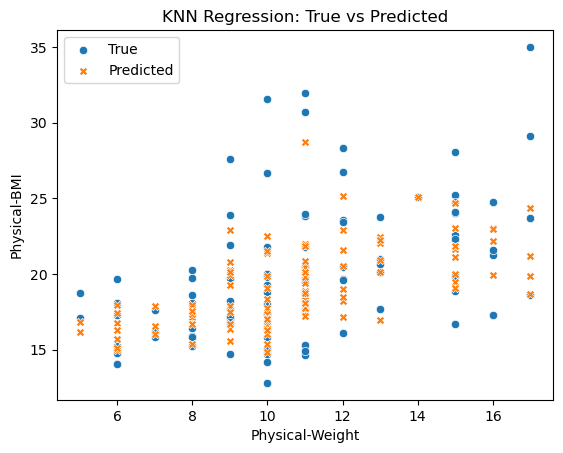

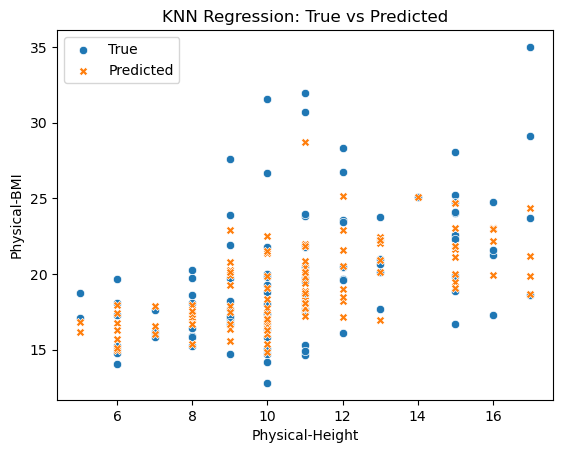

In [161]:
test_df = pd.DataFrame({
    'Physical-Weight': X_test[:, 0],
    'Physical-BMI': y_test})

sns.scatterplot(data=test_df, x='Physical-Weight', y='Physical-BMI', label="True")
sns.scatterplot(data=test_df, x='Physical-Weight', y=knn.predict(X_test), label="Predicted", marker="X")
plt.legend()
plt.title("KNN Regression: True vs Predicted")
plt.show()

test_df1 = pd.DataFrame({
    'Physical-Height': X_test[:, 0],
    'Physical-BMI': y_test})

sns.scatterplot(data=test_df1, x='Physical-Height', y='Physical-BMI', label="True")
sns.scatterplot(data=test_df1, x='Physical-Height', y=knn.predict(X_test), label="Predicted", marker="X")
plt.legend()
plt.title("KNN Regression: True vs Predicted")
plt.show()

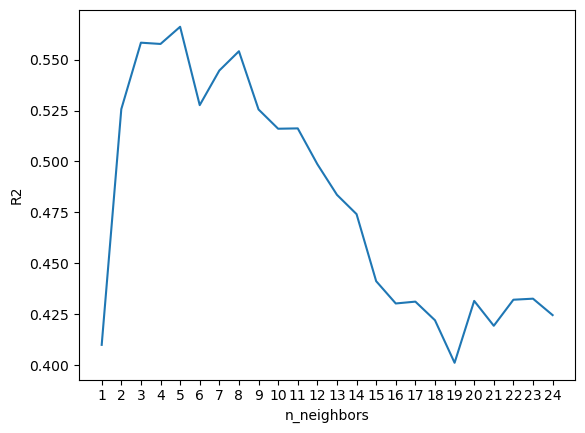

In [162]:
n_neighbors = range(1,25)
scores = list()

for n in n_neighbors:
    knn = KNeighborsRegressor(n_neighbors=n, metric="euclidean", weights="uniform")
    knn.fit(X_train, y_train)
    scores.append(knn.score(X_test, y_test))

plt.plot(scores)
plt.xticks(range(len(n_neighbors)), n_neighbors)
plt.xlabel("n_neighbors")
plt.ylabel("R2")
plt.show()